# Modelación de volatilidad en USD_MXN y gestión del riesgo

The previous notebook, USD_MXN_Macro_Risk_Analysis, empirically demonstrated that the logarithmic returns of the USD/MXN exchange rate operate as an efficient process in its conditional mean, yet exhibit severe heavy-tailed behavior and highly persistent memory in its variance.


Therefore, to build a reliable corporate risk mitigation framework for decision-making, the objective of this notebook is to reject the classical constant variance assumption and implement a GARCH(1,1) model.


The GARCH(1,1) model decomposes the raw residuals of the Mexican Peso into a conditional stochastic process. Notably, the error term exhibits an absolute kurtosis of 6.00. Calibrating the GARCH model under a Gaussian assumption would introduce systematic bias and fail to account for tail risk. Consequently, the standard procedure is to configure the Maximum Likelihood Estimation (MLE) process using a Standardized Student's t-distribution. This allows the model to simultaneously estimate the degrees of freedom parameter, statistically capturing the true thickness of the heavy tails and securing Value-at-Risk (VaR) calculations against extreme devaluation events.

In [1]:
pip install arch

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from statsmodels.stats.diagnostic import het_arch
import scipy.stats as stats
import seaborn as sns
import scipy.stats as stats

In [3]:
#importando los Data necesarios para este apartado:
df_residuos_puros_arima = pd.read_csv('residuos_puros_arima.csv', index_col='Date', parse_dates=True)
df_main_log = pd.read_csv('data_main_log.csv', index_col='Date', parse_dates=True)
df_original_short = pd.read_csv('data_clean_short.csv', index_col='Date', parse_dates=True)

Given that the USD_MXN residuals operate on a very small scale, the 'residuos_usd' variable was rescaled by multiplying it by 100. This standard transformation converts the data into percentage returns, preventing numerical underflow issues and ensuring the optimization algorithm achieves convergence during Maximum Likelihood Estimation (MLE).

In [4]:
# Reescalamiento del residuo de interés
shocks_usd_escalados = df_residuos_puros_arima['residuos_usd'] * 100

# Configuración del motor GARCH(1,1) con la especificación de t-Student
modelo_garch = arch_model(shocks_usd_escalados, vol='Garch', p=1, q=1, dist='studentst')

# 3. Ejecutamos la optimización MLE
resultado_garch = modelo_garch.fit(update_freq=1)

# visualización
resultado_garch.summary()


Iteration:      1,   Func. Count:      7,   Neg. LLF: 15125.443571293385
Iteration:      2,   Func. Count:     19,   Neg. LLF: 6508.641711338363
Iteration:      3,   Func. Count:     29,   Neg. LLF: 35400.58246118987
Iteration:      4,   Func. Count:     36,   Neg. LLF: 1485.9911430955895
Iteration:      5,   Func. Count:     43,   Neg. LLF: 2698.2701341061565
Iteration:      6,   Func. Count:     51,   Neg. LLF: 1341.7963535927806
Iteration:      7,   Func. Count:     58,   Neg. LLF: 1341.705788652589
Iteration:      8,   Func. Count:     64,   Neg. LLF: 1341.7057672048963
Iteration:      9,   Func. Count:     69,   Neg. LLF: 1341.7057672048861
Optimization terminated successfully    (Exit mode 0)
            Current function value: 1341.7057672048963
            Iterations: 9
            Function evaluations: 69
            Gradient evaluations: 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                        Constant Mean - GARCH Model Results                         
====================================================================================
Dep. Variable:                 residuos_usd   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -1341.71
Distribution:      Standardized Student's t   AIC:                           2693.41
Method:                  Maximum Likelihood   BIC:                           2719.59
                                              No. Observations:                 1388
Date:                      Tue, Jul 28 2026   Df Residuals:                     1387
Time:                              22:30:50   Df Model:                            1
                                  Mean Model                                  
==============================================================================
                 coef    std err          t      P>|t|        95.0% Conf. Int.
------------------------------------------------------------------------------
mu            -0.0561  1.539e-02     -3.643  2.700e-04 [-8.621e-02,-2.589e-02]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0451  1.731e-02      2.606  9.161e-03 [1.118e-02,7.905e-02]
alpha[1]       0.1857  4.529e-02      4.100  4.137e-05   [9.690e-02,  0.274]
beta[1]        0.7326  6.662e-02     10.997  3.952e-28     [  0.602,  0.863]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             5.9962      0.932      6.431  1.264e-10 [  4.169,  7.824]
========================================================================

Covariance estimator: robust
"""

GARCH(1,1) Parameter Estimation and Interpretation:


The conditional mean coefficient indicates that, on average, the series centers around -0.05%. The model yields a highly significant p-value of 0.00027, confirming that the constant mean is statistically significant and distinct from random noise.The estimated GARCH parameters demonstrate the following dynamics:


* Omega = 0.0451: The p-value (0.0091) is well below the 0.05 threshold, confirming its statistical significance.


* Alpha = 0.1857: With a highly significant p-value of 0.00004, this coefficient reveals the sensitivity of the Mexican Peso to short-term market shocks. Approximately 18.5% of yesterday's informational shock translates directly into today's conditional variance.


* Beta = 0.7326: The p-value approaches zero, indicating extreme statistical significance. A value of 0.7326 demonstrates strong volatility persistence in the Mexican market. Specifically, 73.2% of yesterday's accumulated volatility carries over into today. Consequently, during market crises, risk does not dissipate quickly; instead, it exhibits prolonged volatility clustering.

The sum of the ARCH and GARCH coefficients alpha + beta = 0.1857 + 0.7326 = 0.9183 is strictly less than 1. This confirms that the model satisfies the covariance stationarity condition. The process is a stable, mean-reverting system where volatility spikes are highly persistent but eventually decay toward the long-term historical average without diverging.


Nu = 5.9962: The degrees of freedom parameter displays an extremely low p-value. A shape parameter close to 6 provides parametric confirmation of severe fat-tailed behavior in the series. This validates that extreme market movements have a higher probability of occurrence than assumed by a Gaussian model, fully justifying why the Normal distribution was rejected for subsequent calculations.


To extract the conditional volatility in its original scale, the arch library provides the .conditional_volatility vector. Since the input returns were rescaled by a factor of 100, this output vector represents the scaled conditional standard deviation. Because the standard deviation is the square root of the variance, the vector must simply be divided by 100 (rather than 10,000) to restore the volatility metrics to their native financial scale.

In [5]:
# Extracción de los coeficientes del modelo de varianza condicional
omega = resultado_garch.params['omega']
alpha = resultado_garch.params['alpha[1]']
beta = resultado_garch.params['beta[1]']

#  Varianza Incondicional (Global)
var_global_inflada = omega / (1 - (alpha + beta))

# corrección de escala
var_global_real = var_global_inflada / 10000

# Volatilidad Global Real calculando la raíz cuadrada
volatilidad_global_real = np.sqrt(var_global_real)

print(f"Varianza Global Real:  {var_global_real:.8f}")
print(f"Volatilidad Global Real:    {volatilidad_global_real:.6f}")
print(f"Volatilidad Global en Porcentaje:   {volatilidad_global_real * 100:.4f}%")

Varianza Global Real:  0.00005520
Volatilidad Global Real:    0.007429
Volatilidad Global en Porcentaje:   0.7429%


To evaluate how the GARCH conditional volatility captures the time-varying dynamics of the ARIMA model residuals, the following DataFrame was constructed.

In [6]:
# Con la finalidad de calcular el resiudo estandarizado Z_t:
#  Extracción de la volatilidad condicional escalada que calculó el GARCH
volatilidad_escalada = resultado_garch.conditional_volatility

# Corrección de escala
volatilidad_original = volatilidad_escalada / 100

# Almacenamiento de volatilidad
df_volatilidad_real = pd.DataFrame({
    'residuos_reales_usd': df_residuos_puros_arima['residuos_usd'],
    'volatilidad_garch_usd': volatilidad_original
}, index=df_residuos_puros_arima.index)

print("Volatilidad condicional")
df_volatilidad_real.head(10)


Volatilidad condicional


,residuos_reales_usd,volatilidad_garch_usd
Date,,
2021-01-05,0.004773,0.008617
2021-01-06,-0.002020,0.008012
2021-01-07,-0.012459,0.007206
2021-01-08,0.017366,0.008297
2021-01-11,0.002516,0.010706
2021-01-12,0.000594,0.009499
2021-01-13,-0.013447,0.008418
2021-01-14,0.002116,0.009341
2021-01-15,-0.005713,0.008353


A granular tracking of the GARCH conditional volatility values confirms the model's sensitivity to real-time market shocks:

* January 6: The baseline conditional volatility was calculated at 0.0080, indicating a period of moderate risk.
* January 7: A negative market innovation of -0.0124 occurred.
* January 8 (The Reaction): The conditional volatility immediately adjusted upward to 0.0082. The model successfully captured the previous day's shock and proactively increased the risk threshold.
* January 8 (The Compounding Shock): Within the same trading day, the market experienced an even larger positive shock of 0.0173.
* January 11 (The Volatility Spike): Following the multi-day compounding shocks, the conditional volatility spiked to 0.0107 at the start of the next trading week, representing a rapid 30% increase in estimated risk.

This real-world sequence empirically validates that the GARCH(1,1) model effectively captures volatility clustering. The shocks from consecutive sessions directly inflated the risk metrics for the subsequent trading week, precisely matching the theoretical expectations established during the initial correlogram analysis. This confirms the model's capacity to accurately map the risk trajectory of the Mexican Peso.

To evaluate whether the conditional heteroskedasticity was successfully filtered out by the GARCH model, the standardized residuals were extracted. Engle's ARCH test was then executed on these residuals to verify that the model correctly captured the dynamic conditional variance, leaving the standardized errors free of remaining ARCH effects.

In [7]:
# Cálculo de los Residuos Estandarizados (z) dividiendo los errores entre su volatilidad real
df_volatilidad_real['residuos_estandarizados'] = (
    df_volatilidad_real['residuos_reales_usd'] / df_volatilidad_real['volatilidad_garch_usd']
)

# Test de ARCH sobre los residuos estandarizados
lm_stat_z, p_value_z, f_stat_z, f_p_value_z = het_arch(
    df_volatilidad_real['residuos_estandarizados'], maxlag=5
)

print("Auditoría de calidad interna")
print(f"Estadístico LM de los residuos estandarizados: {lm_stat_z:.4f}")
print(f"p-valor de control:           {p_value_z:.6f}")

if p_value_z > 0.05:
    print(f"Control de calidad aprobado, p-valor ({p_value_z:.4f}) > 0.05.")
    print("El modelo GARCH absorbió y limpió la aglomeración de volatilidad.")
    print("Los residuos estandarizados estan listos para calcular el VaR corporativo")
else:
    print("Control de calidad rechazado: El modelo dejó turbulencia sin explicar.")


Auditoría de calidad interna
Estadístico LM de los residuos estandarizados: 5.1826
p-valor de control:           0.393999
Control de calidad aprobado, p-valor (0.3940) > 0.05.
El modelo GARCH absorbió y limpió la aglomeración de volatilidad.
Los residuos estandarizados estan listos para calcular el VaR corporativo


/var/folders/jw/23cy6wrx7lj00m30z9y8q01r0000gn/T/ipykernel_35464/1082507756.py:7: FutureWarning: the 'maxlag' keyword is deprecated, use 'nlags' instead.
  lm_stat_z, p_value_z, f_stat_z, f_p_value_z = het_arch(


Following the ARCH test on the standardized residuals, the resulting p-value is 0.3940. Since this value is well above the conventional 0.05 significance level, we fail to reject the null hypothesis of homoskedasticity. This outcome provides statistical proof of the absence of remaining conditional heteroskedasticity in the residuals. It confirms that the GARCH(1,1) model successfully captured the time-varying volatility dynamics of the series, reducing the standardized residuals to a pure, independent stochastic white noise process.

To establish the dynamic Value-at-Risk (VaR) framework, the theoretical quantiles were extracted using the degrees of freedom parameter previously estimated by the GARCH algorithm. Leveraging these metrics, asymmetric 95% and 99% risk thresholds were configured directly onto the logarithmic returns of the exchange rate channel. This procedure analytically defines the maximum thresholds for potential daily financial losses. By directly integrating the time-varying conditional volatility, the model dynamically adapts the capital-at-risk boundaries to mitigate the immediate impact of market uncertainty and structural shocks

In [8]:
# Recuperamos los grados de libertad (nu) estimados el modelo
nu_estimado = resultado_garch.params['nu']

# Extraemos los cuantiles teóricos estrictos de la distribución t-Student Estandarizada
cuantil_95 = stats.t.ppf(0.95, df=nu_estimado)
cuantil_99 = stats.t.ppf(0.99, df=nu_estimado)

print("Cuantiles correspondientes a la distribución:")
print(f"Grados de libertad del canal cambiario (nu): {nu_estimado:.4f}")
print(f"Cuantil Real GARCH-t al 95%:  {cuantil_95:.4f}  (Vs. Gaussiano: 1.6449)")
print(f"Cuantil Real GARCH-t al 99%:  {cuantil_99:.4f}  (Vs. Gaussiano: 2.3263)")


Cuantiles correspondientes a la distribución:
Grados de libertad del canal cambiario (nu): 5.9962
Cuantil Real GARCH-t al 95%:  1.9434  (Vs. Gaussiano: 1.6449)
Cuantil Real GARCH-t al 99%:  3.1433  (Vs. Gaussiano: 2.3263)


In [9]:
# Se crea la matriz del riesgo alineado al precio real y la volatilidad recuperada
df_var = pd.DataFrame(index=df_volatilidad_real.index)
df_var['USD_MXN_real_log'] = df_main_log['USD_MXN_log']
df_var['volatilidad_garch'] = df_volatilidad_real['volatilidad_garch_usd']

# Fabricación de las bandas del VaR al 95% y al 99%
# se multiplica los cuantiles estrictos de tu t-Student por la volatilidad lineal de cada día
df_var['VaR_Sup_95'] = df_var['USD_MXN_real_log'] + (cuantil_95 * df_var['volatilidad_garch'])
df_var['VaR_Inf_95'] = df_var['USD_MXN_real_log'] - (cuantil_95 * df_var['volatilidad_garch'])

df_var['VaR_Sup_99'] = df_var['USD_MXN_real_log'] + (cuantil_99 * df_var['volatilidad_garch'])
df_var['VaR_Inf_99'] = df_var['USD_MXN_real_log'] - (cuantil_99 * df_var['volatilidad_garch'])

print("Protección de valor en riesgo dinámico:")
df_var.head()


Protección de valor en riesgo dinámico:


,USD_MXN_real_log,volatilidad_garch,VaR_Sup_95,VaR_Inf_95,VaR_Sup_99,VaR_Inf_99
Date,,,,,,
2021-01-05,2.992851,0.008617,3.009597,2.976105,3.019936,2.965765
2021-01-06,2.990830,0.008012,3.006400,2.975260,3.016014,2.965647
2021-01-07,2.978371,0.007206,2.992376,2.964366,3.001023,2.955719
2021-01-08,2.995737,0.008297,3.011862,2.979612,3.021818,2.969656
2021-01-11,2.998254,0.010706,3.019059,2.977448,3.031905,2.964602


Con la finalidad de observar de manera gráfica, con soltura se puede graficar de la siguiente manera

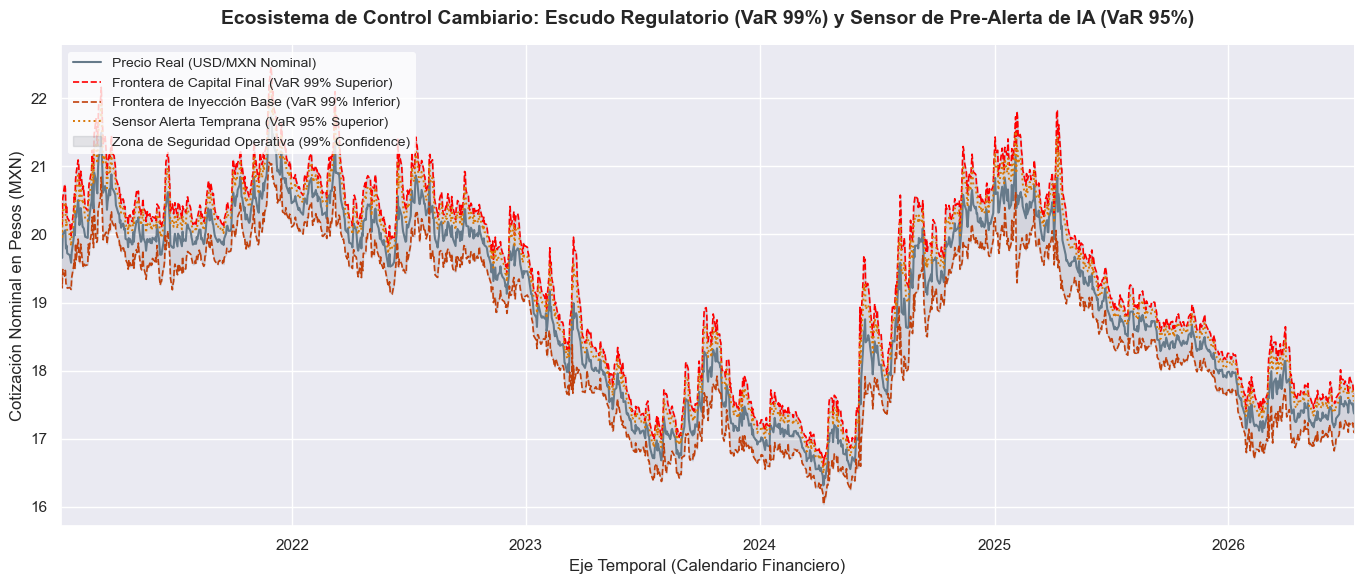

In [10]:
# conversión a la escala ordinaria
df_var['VaR_Sup_99_pesos'] = np.exp(df_var['VaR_Sup_99'])
df_var['VaR_Inf_99_pesos'] = np.exp(df_var['VaR_Inf_99'])
df_var['VaR_Sup_95_pesos'] = np.exp(df_var['VaR_Sup_95']) 

sns.set_theme(style="darkgrid")

g = sns.relplot(
    data=df_original_short,
    x=df_original_short.index,
    y='USD_MXN', # Escala nominal de pesos originales viva en df_main_clean_short
    kind='line',
    color='#667a8a',
    linewidth=1.5,
    height=6,        
    aspect=2.3  
)

# Líneas de contención del 99%
sns.lineplot(data=df_var, x=df_var.index, y='VaR_Sup_99_pesos', color='red', linestyle='--', linewidth=1.2, ax=g.ax)
sns.lineplot(data=df_var, x=df_var.index, y='VaR_Inf_99_pesos', color='#c2410c', linestyle='--', linewidth=1.2, ax=g.ax)

# Línea de Pre-Alerta del 95%
sns.lineplot(data=df_var, x=df_var.index, y='VaR_Sup_95_pesos', color='#d97706', linestyle=':', linewidth=1.4, ax=g.ax)

# Región de Confianza del 99%
g.ax.fill_between(
    df_var.index, 
    df_var['VaR_Inf_99_pesos'], 
    df_var['VaR_Sup_99_pesos'], 
    color='#0f172a', 
    alpha=0.1
)

g.ax.set_title('Ecosistema de Control Cambiario: Escudo Regulatorio (VaR 99%) y Sensor de Pre-Alerta de IA (VaR 95%)', fontsize=14, fontweight='bold', pad=15)
g.set_axis_labels('Eje Temporal (Calendario Financiero)', 'Cotización Nominal en Pesos (MXN)', fontsize=12)

g.ax.legend(
    handles=g.ax.get_lines() + [plt.Rectangle((0,0),1,1, color='#0f172a', alpha=0.1)],
    labels=[
        'Precio Real (USD/MXN Nominal)', 
        'Frontera de Capital Final (VaR 99% Superior)', 
        'Frontera de Inyección Base (VaR 99% Inferior)', 
        'Sensor Alerta Temprana (VaR 95% Superior)',
        'Zona de Seguridad Operativa (99% Confidence)'
    ],
    loc='upper left', 
    frameon=True, 
    facecolor='white', 
    edgecolor='none',
    fontsize=10
)

g.ax.autoscale(enable=True, axis='x', tight=True)

plt.tight_layout()
plt.show()


Dynamic Value-at-Risk (VaR) Visualization Analysis

The control chart demonstrates that the 95% and 99% upper and lower VaR thresholds are neither parallel nor static. Instead, these risk boundaries adapt dynamically, reflecting the time-varying nature of market volatility.

During periods of macroeconomic stability, the risk intervals contract tightly around the actual price (original scale in Pesos) of the USD/MXN exchange rate. This behavior optimizes the organization's capital efficiency, proving that excessive capital reserves or collateral do not need to remain idle during low-risk regimes.

Conversely, during sudden market stress events, the upper risk boundaries expand immediately and aggressively. By capturing volatility persistence, the conditional variance model incorporates recent market shocks to re-estimate risk thresholds. This provides the corporate treasury with a realistic calculation of the optimal capital required to safeguard the balance sheet, effectively mitigating margin calls and liquidity risks during severe currency devaluations.

Subsequently, a one-tailed directional backtest is specified (returns > VaR_{99}) because the model simulates the risk management of a Mexican corporate entity asymmetrically exposed to Peso depreciations. To validate the model's accuracy, a Basel-compliant backtesting procedure is implemented. This test determines whether the frequency of VaR exceptions (breaches) falls within the acceptable parameters established by the Basel Committee on Banking Supervision.

In [11]:
# Auditoría del riesgo cambiario de devaluación con la finalidad de evaluar si el residuo supera la banda del VaR superior

residuos_usd = df_volatilidad_real['residuos_reales_usd']
var_limite_99 = cuantil_99 * df_volatilidad_real['volatilidad_garch_usd']

# Definición de violación al blindaje
violaciones_99 = residuos_usd > var_limite_99
N_fallas = violaciones_99.sum()
T_total = len(residuos_usd)
proporcion_fallas = N_fallas / T_total

#  Test de Proporciones de Kupiec
p_teorico = 0.01  
# Ecuación de Verosimilitud bajo la hipótesis nula
L_H0 = ((1 - p_teorico)**(T_total - N_fallas)) * (p_teorico**N_fallas)

# Ecuación de Verosimilitud bajo la hipótesis alternativa 
L_H1 = ((1 - proporcion_fallas)**(T_total - N_fallas)) * (proporcion_fallas**N_fallas)

# Estadístico LR:
LR_kupiec = -2 * np.log(L_H0 / L_H1)

p_valor_kupiec = 1 - stats.chi2.cdf(LR_kupiec, df=1)

print(f"Tamaño de la Muestra Temporal (T):   {T_total} días")
print(f"Número de Violaciones Reales (N):     {N_fallas} fallas observadas")
print(f"Proporción Real de Fallas:            {proporcion_fallas*100:.4f}% (Vs. Teórica: 1.00%)")
print(f"Estadístico LR de Kupiec:            {LR_kupiec:.4f}")
print(f"p-valor de Basilea:            {p_valor_kupiec:.6f}")
print("==================================================================")

if p_valor_kupiec > 0.05:
    print(f"El modelo se encuentra certificado, p-valor ({p_valor_kupiec:.4f}) > 0.05.")
else:
    print("Modelo rechazado")


Tamaño de la Muestra Temporal (T):   1388 días
Número de Violaciones Reales (N):     10 fallas observadas
Proporción Real de Fallas:            0.7205% (Vs. Teórica: 1.00%)
Estadístico LR de Kupiec:            1.2137
p-valor de Basilea:            0.270607
El modelo se encuentra certificado, p-valor (0.2706) > 0.05.


VaR Backtesting and Kupiec Coverage Validation


To evaluate the operational performance of the GARCH(1,1) model under a Student's t-distribution, an empirical out-of-sample backtest was executed. This simulation compared actual daily market innovations against the model's calculated 99% Value-at-Risk (VaR) boundary. Subsequently, Kupiec's Proportion of Overcharges (POF) Inconditional Coverage Test was performed to rigorously evaluate the statistical frequency of the breaches.

The resulting p-value of 0.2706 sits comfortably above the critical 5% significance threshold, statistically validating the parametric accuracy of the risk framework. Under the strict banking supervision criteria established by the Basel Committee, the model falls into the Green Zone (Approval Zone). This outcome proves that the parametric configuration using the Student's t-distribution accurately captured the heavy-tailed behavior dictated by the empirical leptokurtosis of the Mexican Peso.

 Consequently, the corporate treasury can deploy a certified Dynamic VaR framework that optimizes financial collateral allocation. The model effectively protects the organization against margin calls and liquidity constraints without incurring the opportunity cost of holding excessive, unutilized capital.

In [12]:
# Guardamos la matriz maestra de volatilidad y VaR certificada por Basilea
df_var.to_csv('matriz_volatilidad_var_garch.csv', index=True)

print("Características de riesgo certificadas exportadas")


Características de riesgo certificadas exportadas
